In [28]:
#  pip install pyspark
# sudo apt-get update
# sudo apt-get install openjdk-17-jdk
# export JAVA_HOME=/usr/lib/jvm/java-17-openjdk-amd64
# export PATH=$JAVA_HOME/bin:$PATH


In [29]:
from pyspark.sql import SparkSession
import os

# java env
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"

spark = SparkSession.builder.appName("A3").getOrCreate()
print(spark)


In [30]:
import shutil
import os

def save_as_single_csv(df, output_filename):
    """
    Save a Spark DataFrame as a single CSV file with the exact filename.
    Spark normally writes multiple part files to a directory; this function
    coalesces to 1 partition and renames the part file to the desired filename.
    """
    tmp_dir = output_filename + "_tmp"

    # 1. Coalesce to 1 partition → ensures only 1 part file
    df.coalesce(1).write.csv(tmp_dir, header=True, mode="overwrite")

    # 2. Find generated part file
    part_file = None
    for f in os.listdir(tmp_dir):
        if f.startswith("part-") and f.endswith(".csv"):
            part_file = f
            break

    if not part_file:
        raise RuntimeError("No part-00000 CSV file found in temp directory")

    # 3. Move and rename to desired output filename
    shutil.move(os.path.join(tmp_dir, part_file), output_filename)

    # 4. Delete temp directory
    shutil.rmtree(tmp_dir)


## r1

Output the total number of berthages for each section. The output file should have
the columns section and count. (10 points)

In [31]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import countDistinct

spark = SparkSession.builder.appName("A3").getOrCreate()

df = spark.read.csv("parking_data_sz.csv", header=True)

# Task 1
r1 = df.groupBy("section") \
       .agg(countDistinct("berthage").alias("count"))

# Save r1 as r1.csv
save_as_single_csv(r1, "r1.csv")


## r2

Output all unique berthagesfor each section. The output file should have the columns
berthage and section. (20 points)


In [32]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col

spark = SparkSession.builder.appName("A3").getOrCreate()
df = spark.read.csv("parking_data_sz.csv", header=True)

# Task 2
r2 = df.select("berthage", "section").distinct()

# Save r2
save_as_single_csv(r2, "r2.csv")


## r3

Output the average parking time for each section. The output file should have the
columns section and avg_parking_time. The average parking time should be
an integer representing seconds (i.e., cast the value to Python int). (20 points)


In [33]:
from pyspark.sql.functions import unix_timestamp, avg

# Filter invalid rows
df_valid = df.filter(unix_timestamp("out_time") > unix_timestamp("in_time"))

# Compute parking time in seconds
df_time = df_valid.withColumn(
    "parking_seconds",
    unix_timestamp("out_time") - unix_timestamp("in_time")
)

# Task 3: avg parking time per section
r3 = df_time.groupBy("section") \
            .agg(avg("parking_seconds").cast("int").alias("avg_parking_time"))

# Save r3
save_as_single_csv(r3, "r3.csv")


## r4

Output the average parking time for each berthage, sorted in descending order. The
output file should have the columns berthage and avg_parking_time. The average parking time should be an integer representing seconds (i.e., cast the value to
Python int). (20 points)

In [34]:
# Task 4: avg parking time per berthage
r4 = df_time.groupBy("berthage") \
            .agg(avg("parking_seconds").cast("int").alias("avg_parking_time")) \
            .orderBy(col("avg_parking_time").desc())

# Save r4
save_as_single_csv(r4, "r4.csv")


## r5

For each section, output the total number of berthages in use and the percentage
of in-use berthages in that section, in a one-hour interval (e.g. during 09:00:00-
10:00:00). “In use” means there is at least one vehicle parked in that berthage
in that interval for ANY duration. The time intervals should begin at the start
of the first hour that appears in the dataset (for example, if the first entry is at
12:23, the first interval should start from 12:00). The output file should have the
columns start_time, end_time, section, count and percentage. The percentage value should be rounded to one decimal place (e.g. 67.8%). The data format of start_time and end_time should match the one in the original dataset
“YYYY-MM-DD HH:MM:SS” (20 points)


In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    to_timestamp, unix_timestamp, date_trunc, sequence, explode,
    countDistinct, count, col, expr, round, concat, lit, date_format
)

# 1. Filter invalid rows
df_ts = df.withColumn("in_ts",  to_timestamp("in_time")) \
          .withColumn("out_ts", to_timestamp("out_time"))

df_valid = df_ts.filter(col("out_ts") > col("in_ts"))

# 2. preprocess time, construct all full hour_start covered by [in_ts, out_ts)
#    To avoid counting the hour that is exactly the out_ts, use out_ts - 1 SECOND
df_valid = df_valid.withColumn("out_adj", expr("out_ts - INTERVAL 1 SECOND"))

# Each record's first and last hour_start (truncated to hour)
df_valid = df_valid.withColumn("start_hour", date_trunc("hour", col("in_ts"))) \
                   .withColumn("end_hour",   date_trunc("hour", col("out_adj")))

# Generate array of hour_start timestamps covered by [start_hour, end_hour]
df_valid = df_valid.withColumn(
    "hour_start_array",
    sequence(col("start_hour"), col("end_hour"), expr("INTERVAL 1 HOUR"))
)

# Expand into multiple rows: each row is a (section, berthage, hour_start)
df_expanded = df_valid.select(
    "section",
    "berthage",
    explode(col("hour_start_array")).alias("hour_start")
)

# 3. Calculate total berthage count for each section (global, not time-specific)
section_total = df.select("section", "berthage") \
                  .distinct() \
                  .groupBy("section") \
                  .agg(count("berthage").alias("total_berthages"))

# 4. Calculate the number of "in use" berthages (distinct) for each (section, hour_start)
in_use = df_expanded.groupBy("section", "hour_start") \
                    .agg(countDistinct("berthage").alias("count"))

# 5. Calculate percentage + add start_time / end_time fields
r5 = in_use.join(section_total, on="section", how="left")

r5 = r5.withColumn(
        "percentage_num",
        round(col("count") * 100.0 / col("total_berthages"), 1)
    ) \
    .withColumn(
        "percentage",
        concat(col("percentage_num").cast("string"), lit("%"))
    ) \
    .withColumn(
        "start_time",
        date_format(col("hour_start"), "yyyy-MM-dd HH:mm:ss")
    ) \
    .withColumn(
        "end_time",
        date_format(expr("hour_start + INTERVAL 1 HOUR"), "yyyy-MM-dd HH:mm:ss")
    ) \
    .select(
        "start_time",
        "end_time",
        "section",
        "count",
        "percentage"
    ) \
    .orderBy("start_time", "section")

# 6. Save as r5.csv
save_as_single_csv(r5, "r5.csv")


### Subtask

Select three sections from the results and plot a figure with time
as the X axis and percentage as the Y axis. Analyse the results and state any
interesting trends that you identify in the report. (10 points)

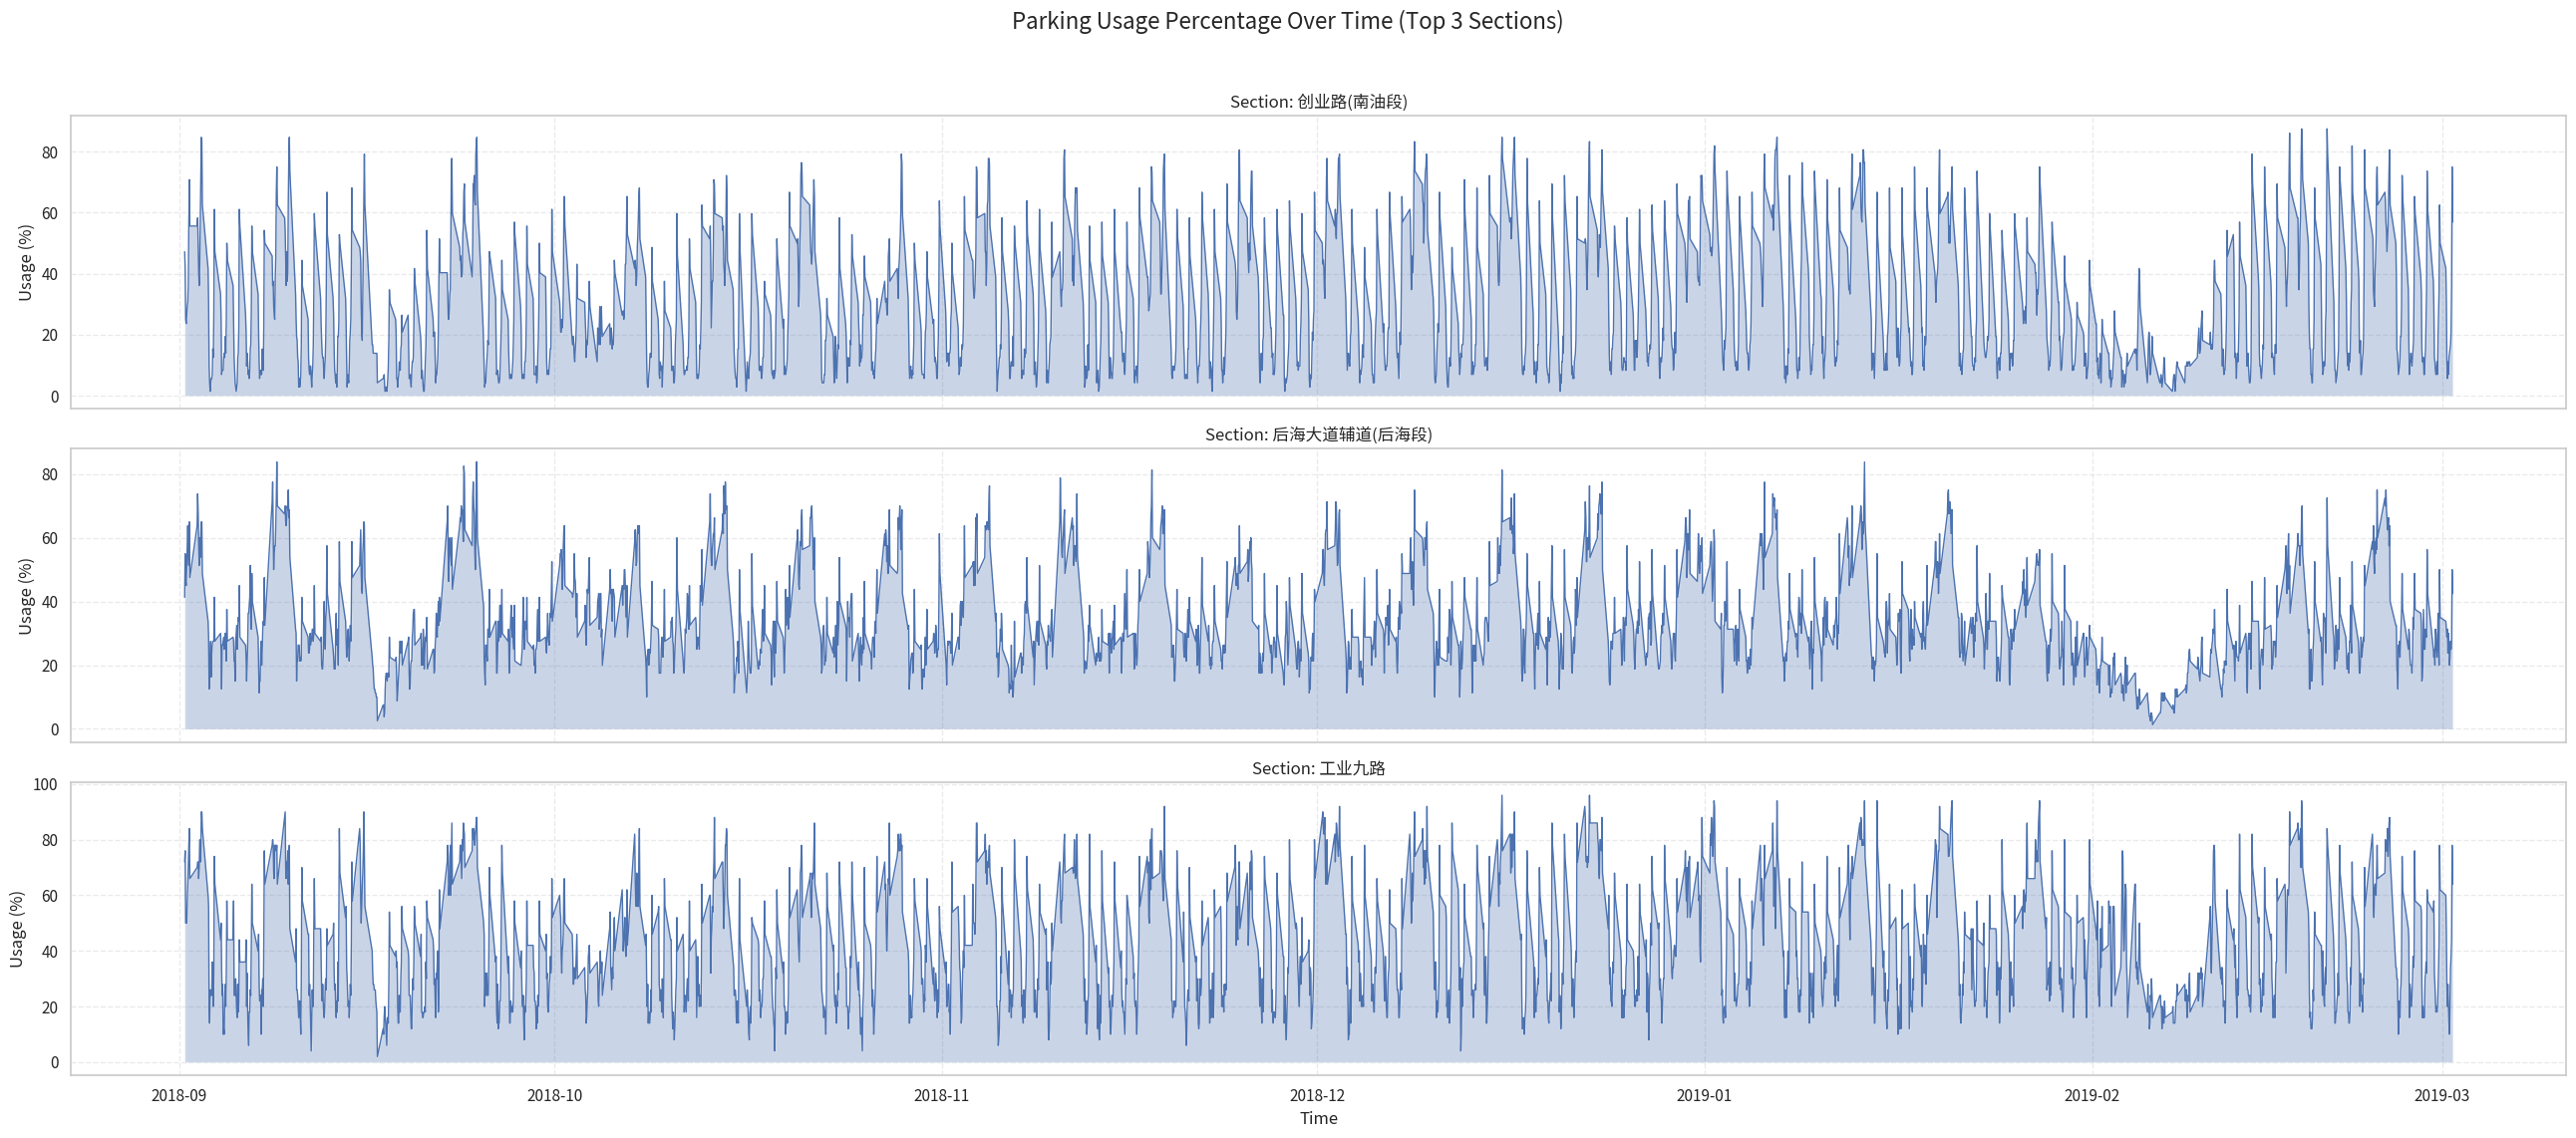

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 1. Change this to your Noto Sans SC font path
font_path = "/home/haibin/distributed_system/assignment3/static/NotoSansSC-Regular.ttf"

# 2. Explicitly register this font with matplotlib
fm.fontManager.addfont(font_path)

# 3. Set the global default font to Noto Sans SC
plt.rcParams["font.family"] = "Noto Sans SC"
plt.rcParams["axes.unicode_minus"] = False


# 1. Read data
df = pd.read_csv("r5.csv")
df["percentage"] = df["percentage"].str.replace("%", "").astype(float)
df["start_time"] = pd.to_datetime(df["start_time"])

# 2. Select the top 3 most frequent sections
top_sections = (
    df["section"]
    .value_counts()
    .head(3)
    .index
    .tolist()
)

df_sel = df[df["section"].isin(top_sections)]
df_sel = df_sel.sort_values(["section", "start_time"])

# 3. Plot three subplots
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(26, 12), sharex=True)

# ------ ensure axes is a 1D list ------
if isinstance(axes, np.ndarray):
    axes = axes.flatten().tolist()
else:
    axes = [axes]
# ---------------------------------------

for ax, sec in zip(axes, top_sections):
    sub = df_sel[df_sel["section"] == sec]
    
    ax.plot(sub["start_time"], sub["percentage"], linewidth=1)
    ax.fill_between(sub["start_time"], sub["percentage"], alpha=0.3)

    ax.set_ylabel("Usage (%)")
    ax.set_title(f"Section: {sec}")
    ax.grid(True, linestyle="--", alpha=0.4)

axes[-1].set_xlabel("Time")

fig.suptitle("Parking Usage Percentage Over Time (Top 3 Sections)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()


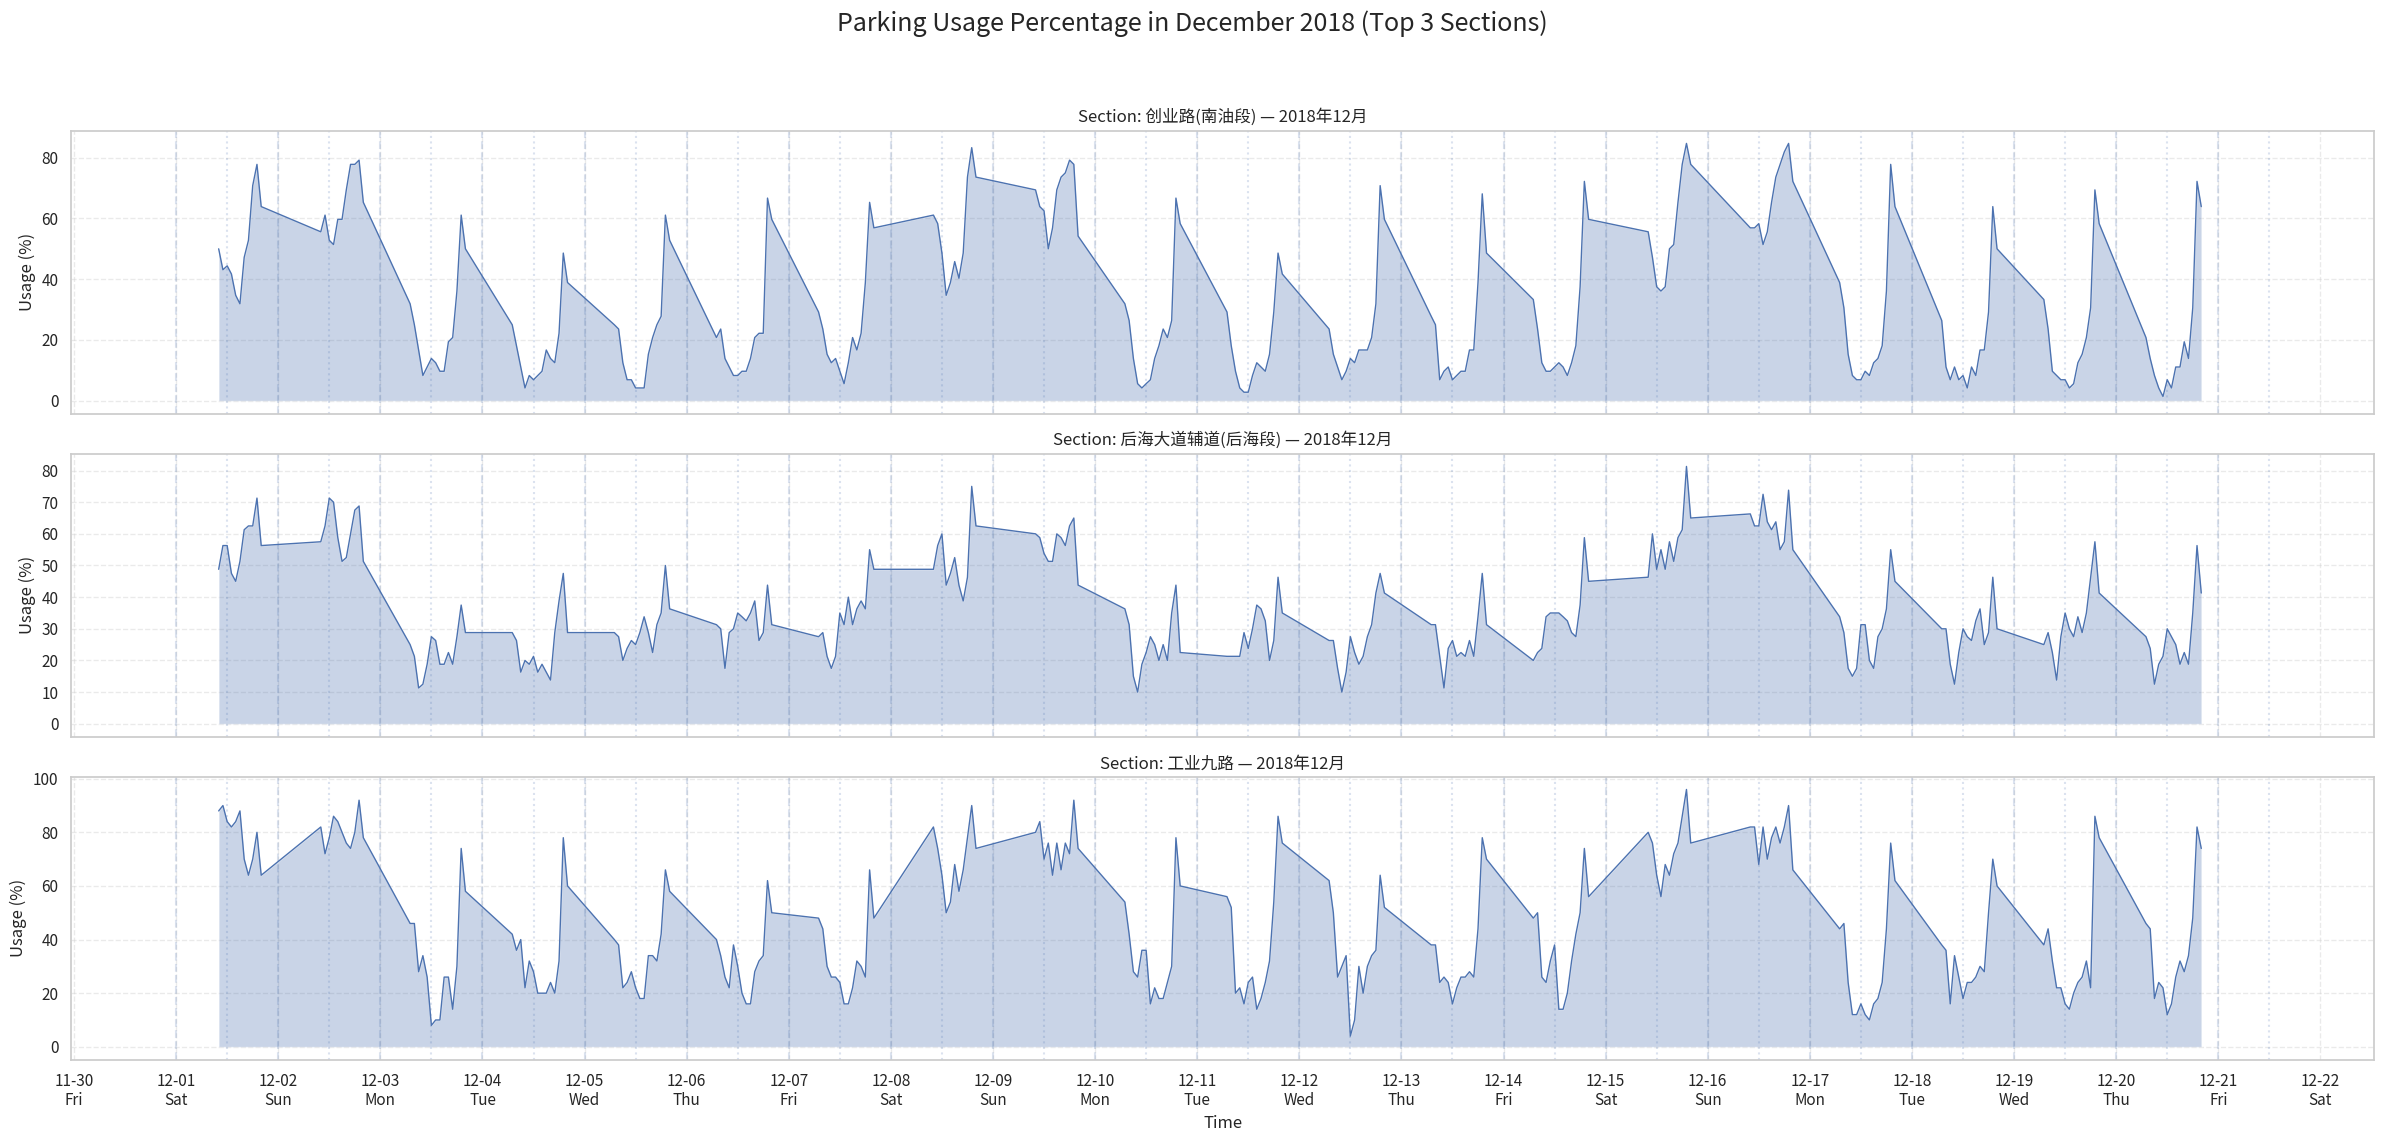

In [80]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm
import matplotlib.dates as mdates

# -------- 字体设置 --------
font_path = "/home/haibin/distributed_system/assignment3/static/NotoSansSC-Regular.ttf"
fm.fontManager.addfont(font_path)
plt.rcParams["font.family"] = "Noto Sans SC"
plt.rcParams["axes.unicode_minus"] = False
# --------------------------

# 1. Load data
df = pd.read_csv("r5.csv")
df["percentage"] = df["percentage"].str.replace("%", "").astype(float)
df["start_time"] = pd.to_datetime(df["start_time"])

number = 3

# 2. 选择 12 月最常出现的 3 个 section
top_sections = (
    df["section"]
    .value_counts()
    .head(number)
    .index
    .tolist()
)

# 3. 只保留 2018-12 的数据
df_dec = df[
    (df["start_time"] >= "2018-12-01") &
    (df["start_time"] <  "2018-12-21")
]

df_sel = df_dec[df_dec["section"].isin(top_sections)]
df_sel = df_sel.sort_values(["section", "start_time"])

# 4. 创建子图
fig, axes = plt.subplots(nrows=number, ncols=1, figsize=(24, number * 4), sharex=True)

if isinstance(axes, np.ndarray):
    axes = axes.flatten().tolist()
else:
    axes = [axes]

# ====== 预先算好每天的 0:00 和 12:00 ======
# 所有日期（按天归一化）
all_days = pd.date_range("2018-12-01", "2018-12-21", freq="D")
midnights = all_days                # 每天 00:00
noons = all_days + pd.Timedelta(hours=12)  # 每天 12:00
# ======================================

for ax, sec in zip(axes, top_sections):
    sub = df_sel[df_sel["section"] == sec]
    
    # 曲线 + 面积
    ax.plot(sub["start_time"], sub["percentage"], linewidth=1)
    ax.fill_between(sub["start_time"], sub["percentage"], alpha=0.3)

    # 画每天 0:00 的竖线（虚线），用来分隔日期
    for t in midnights:
        ax.axvline(t, linestyle="--", alpha=0.2)

    # 画每天 12:00 的竖线（点划线）
    for t in noons:
        ax.axvline(t, linestyle=":", alpha=0.2)

    ax.set_ylabel("Usage (%)")
    ax.set_title(f"Section: {sec} — 2018年12月")
    ax.grid(True, linestyle="--", alpha=0.4)

# X 轴：日期 + 星期几，比如 12-01\nSat
locator = mdates.DayLocator(interval=1)  # 每天一个刻度
formatter = mdates.DateFormatter("%m-%d\n%a")  # 月-日 + 星期（Mon/Tue/...）

for ax in axes:
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)

axes[-1].set_xlabel("Time")

fig.suptitle(f"Parking Usage Percentage in December 2018 (Top {number} Sections)", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
